<a href="https://colab.research.google.com/github/muminat58/dsrp_2026/blob/main/DSPR_2026_Muminat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score

In [2]:
df = pd.read_csv('/content/NCD_RisC_Nature_2020_Cholesterol_age_standardised_countries.csv')
df.head(15600)

,Country/Region/World,ISO,Sex,Year,Mean total cholesterol (mmol/L),Mean total cholesterol lower 95% uncertainty interval (mmol/L),Mean total cholesterol upper 95% uncertainty interval (mmol/L),Mean non-HDL cholesterol (mmol/L),Mean non-HDL cholesterol lower 95% uncertainty interval (mmol/L),Mean non-HDL cholesterol upper 95% uncertainty interval (mmol/L),Mean HDL cholesterol (mmol/L),Mean HDL cholesterol lower 95% uncertainty interval (mmol/L),Mean HDL cholesterol upper 95% uncertainty interval (mmol/L)
0,Afghanistan,AFG,Men,1980,4.263545,3.539636,4.959936,2.919134,2.486837,3.339214,1.221839,0.926460,1.497237
1,Afghanistan,AFG,Men,1981,4.266327,3.569655,4.931141,2.934723,2.512884,3.344176,1.214738,0.932500,1.476955
2,Afghanistan,AFG,Men,1982,4.269252,3.612601,4.904159,2.950451,2.543536,3.345615,1.207716,0.935305,1.462378
3,Afghanistan,AFG,Men,1983,4.272437,3.646602,4.881011,2.966397,2.570361,3.353339,1.200752,0.943039,1.444552
4,Afghanistan,AFG,Men,1984,4.275822,3.673783,4.866126,2.982507,2.598309,3.360546,1.193839,0.947619,1.427836
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15595,Zimbabwe,ZWE,Women,2014,4.161298,3.755729,4.588048,2.945255,2.711719,3.174748,1.312036,1.140103,1.483028
15596,Zimbabwe,ZWE,Women,2015,4.157357,3.710967,4.625261,2.945829,2.704246,3.184318,1.310691,1.126460,1.491962
15597,Zimbabwe,ZWE,Women,2016,4.153718,3.661819,4.663383,2.946790,2.694693,3.195830,1.309282,1.110321,1.504699
15598,Zimbabwe,ZWE,Women,2017,4.150368,3.608575,4.709977,2.948084,2.683316,3.207449,1.307992,1.093114,1.517367


In [3]:
df.shape

(15600, 13)

In [4]:
df.drop_duplicates(inplace=True)
df.shape


(15600, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15600 entries, 0 to 15599
Data columns (total 13 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Country/Region/World                                              15600 non-null  object 
 1   ISO                                                               15600 non-null  object 
 2   Sex                                                               15600 non-null  object 
 3   Year                                                              15600 non-null  int64  
 4   Mean total cholesterol (mmol/L)                                   15600 non-null  float64
 5   Mean total cholesterol lower 95% uncertainty interval (mmol/L)    15600 non-null  float64
 6   Mean total cholesterol upper 95% uncertainty interval (mmol/L)    15600 non-null  float64
 7   Mean non-HDL cholesterol (mmol/

In [6]:
df.isna().sum()

,0
Country/Region/World,0
ISO,0
Sex,0
Year,0
Mean total cholesterol (mmol/L),0
Mean total cholesterol lower 95% uncertainty interval (mmol/L),0
Mean total cholesterol upper 95% uncertainty interval (mmol/L),0
Mean non-HDL cholesterol (mmol/L),0
Mean non-HDL cholesterol lower 95% uncertainty interval (mmol/L),0
Mean non-HDL cholesterol upper 95% uncertainty interval (mmol/L),0


In [7]:
df.dtypes

,0
Country/Region/World,object
ISO,object
Sex,object
Year,int64
Mean total cholesterol (mmol/L),float64
Mean total cholesterol lower 95% uncertainty interval (mmol/L),float64
Mean total cholesterol upper 95% uncertainty interval (mmol/L),float64
Mean non-HDL cholesterol (mmol/L),float64
Mean non-HDL cholesterol lower 95% uncertainty interval (mmol/L),float64
Mean non-HDL cholesterol upper 95% uncertainty interval (mmol/L),float64


In [8]:
df.describe()

,Year,Mean total cholesterol (mmol/L),Mean total cholesterol lower 95% uncertainty interval (mmol/L),Mean total cholesterol upper 95% uncertainty interval (mmol/L),Mean non-HDL cholesterol (mmol/L),Mean non-HDL cholesterol lower 95% uncertainty interval (mmol/L),Mean non-HDL cholesterol upper 95% uncertainty interval (mmol/L),Mean HDL cholesterol (mmol/L),Mean HDL cholesterol lower 95% uncertainty interval (mmol/L),Mean HDL cholesterol upper 95% uncertainty interval (mmol/L)
count,15600.000000,15600.000000,15600.000000,15600.000000,15600.000000,15600.000000,15600.000000,15600.000000,15600.000000,15600.000000
mean,1999.000000,4.640884,4.267456,5.014135,3.409580,3.161987,3.656869,1.182812,1.011043,1.353301
std,11.254989,0.526163,0.593618,0.486433,0.541564,0.594014,0.498885,0.160172,0.194039,0.148257
min,1980.000000,3.420384,2.852869,3.688879,1.974066,1.482944,2.359677,0.707361,0.537585,0.852706
25%,1989.000000,4.233475,3.814052,4.641863,3.013087,2.730124,3.287278,1.071247,0.862170,1.256041
50%,1999.000000,4.631519,4.253378,5.002064,3.457274,3.223492,3.688262,1.146994,0.967051,1.338588
75%,2009.000000,4.977998,4.664222,5.305254,3.791976,3.578849,3.999924,1.267988,1.133620,1.430700
max,2018.000000,6.242019,5.981153,6.676697,5.080015,4.834224,5.341918,1.773267,1.700269,1.936919


In [9]:
middle_eastern_countries = [
    'Afghanistan', 'Bahrain', 'Iran', 'Iraq', 'Israel', 'Jordan', 'Kuwait',
    'Lebanon', 'Oman', 'Occupied Palestinian Territory', 'Qatar', 'Saudi Arabia',
    'Syria', 'Turkey', 'United Arab Emirates', 'Yemen'
]
south_african_countries = [
    'South Africa', 'Angola', 'Botswana', 'Comoros', 'Eswatini', 'Lesotho', 'Madagascar',
    'Malawi', 'Mauritius', 'Mozambique', 'Namibia', 'Zambia', 'Zimbabwe'
]

def get_region(country):
    if country in middle_eastern_countries:
        return 'Middle East'
    elif country in south_african_countries:
        return 'South Africa'
    else:
        return 'Other'

df['Region'] = df['Country/Region/World'].apply(get_region)

df.head()

,Country/Region/World,ISO,Sex,Year,Mean total cholesterol (mmol/L),Mean total cholesterol lower 95% uncertainty interval (mmol/L),Mean total cholesterol upper 95% uncertainty interval (mmol/L),Mean non-HDL cholesterol (mmol/L),Mean non-HDL cholesterol lower 95% uncertainty interval (mmol/L),Mean non-HDL cholesterol upper 95% uncertainty interval (mmol/L),Mean HDL cholesterol (mmol/L),Mean HDL cholesterol lower 95% uncertainty interval (mmol/L),Mean HDL cholesterol upper 95% uncertainty interval (mmol/L),Region
0,Afghanistan,AFG,Men,1980,4.263545,3.539636,4.959936,2.919134,2.486837,3.339214,1.221839,0.926460,1.497237,Middle East
1,Afghanistan,AFG,Men,1981,4.266327,3.569655,4.931141,2.934723,2.512884,3.344176,1.214738,0.932500,1.476955,Middle East
2,Afghanistan,AFG,Men,1982,4.269252,3.612601,4.904159,2.950451,2.543536,3.345615,1.207716,0.935305,1.462378,Middle East
3,Afghanistan,AFG,Men,1983,4.272437,3.646602,4.881011,2.966397,2.570361,3.353339,1.200752,0.943039,1.444552,Middle East
4,Afghanistan,AFG,Men,1984,4.275822,3.673783,4.866126,2.982507,2.598309,3.360546,1.193839,0.947619,1.427836,Middle East


In [10]:
columns_to_drop = [
    'Mean total cholesterol lower 95% uncertainty interval (mmol/L)',
    'Mean total cholesterol upper 95% uncertainty interval (mmol/L)',
    'Mean non-HDL cholesterol (mmol/L)',
    'Mean non-HDL cholesterol lower 95% uncertainty interval (mmol/L)',
    'Mean non-HDL cholesterol upper 95% uncertainty interval (mmol/L)',
    'Mean HDL cholesterol (mmol/L)',
    'Mean HDL cholesterol lower 95% uncertainty interval (mmol/L)',
    'Mean HDL cholesterol upper 95% uncertainty interval (mmol/L)'
]
df.drop(columns=columns_to_drop, inplace=True)
df.head()

,Country/Region/World,ISO,Sex,Year,Mean total cholesterol (mmol/L),Region
0,Afghanistan,AFG,Men,1980,4.263545,Middle East
1,Afghanistan,AFG,Men,1981,4.266327,Middle East
2,Afghanistan,AFG,Men,1982,4.269252,Middle East
3,Afghanistan,AFG,Men,1983,4.272437,Middle East
4,Afghanistan,AFG,Men,1984,4.275822,Middle East


In [11]:
df = df[df['Sex'] != 'Men']
df.head()

,Country/Region/World,ISO,Sex,Year,Mean total cholesterol (mmol/L),Region
7800,Afghanistan,AFG,Women,1980,4.185578,Middle East
7801,Afghanistan,AFG,Women,1981,4.195018,Middle East
7802,Afghanistan,AFG,Women,1982,4.204503,Middle East
7803,Afghanistan,AFG,Women,1983,4.213971,Middle East
7804,Afghanistan,AFG,Women,1984,4.223569,Middle East


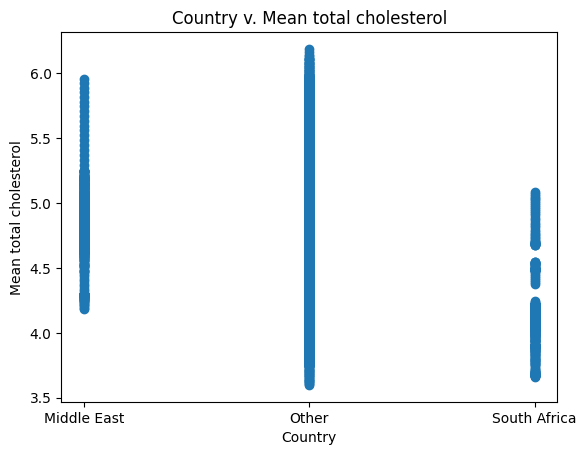

In [12]:
plt.scatter(df["Region"], df["Mean total cholesterol (mmol/L)"])
plt.title("Country v. Mean total cholesterol")
plt.xlabel("Country")
plt.ylabel("Mean total cholesterol")
plt.show()


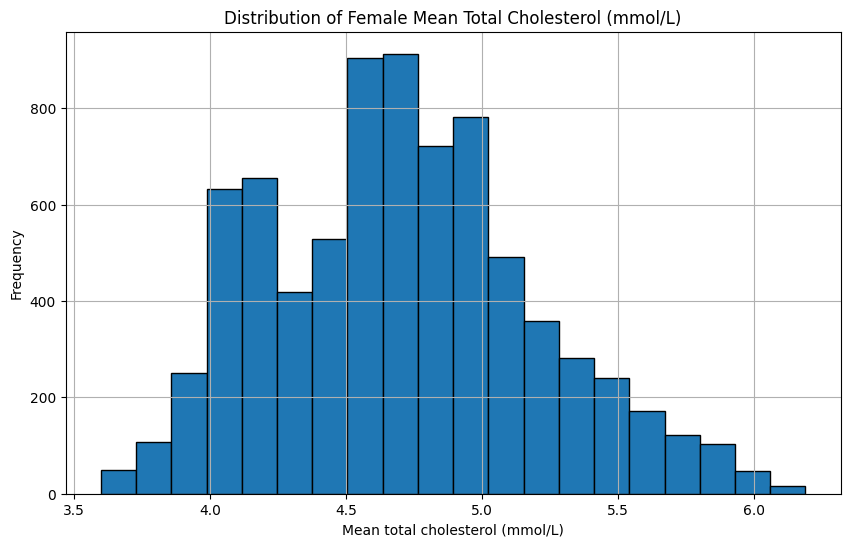

In [18]:
female_df = df[df['Sex'] == 'Women']

plt.figure(figsize=(10, 6))
plt.hist(female_df['Mean total cholesterol (mmol/L)'], bins=20, edgecolor='black')
plt.title('Distribution of Female Mean Total Cholesterol (mmol/L)')
plt.xlabel('Mean total cholesterol (mmol/L)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

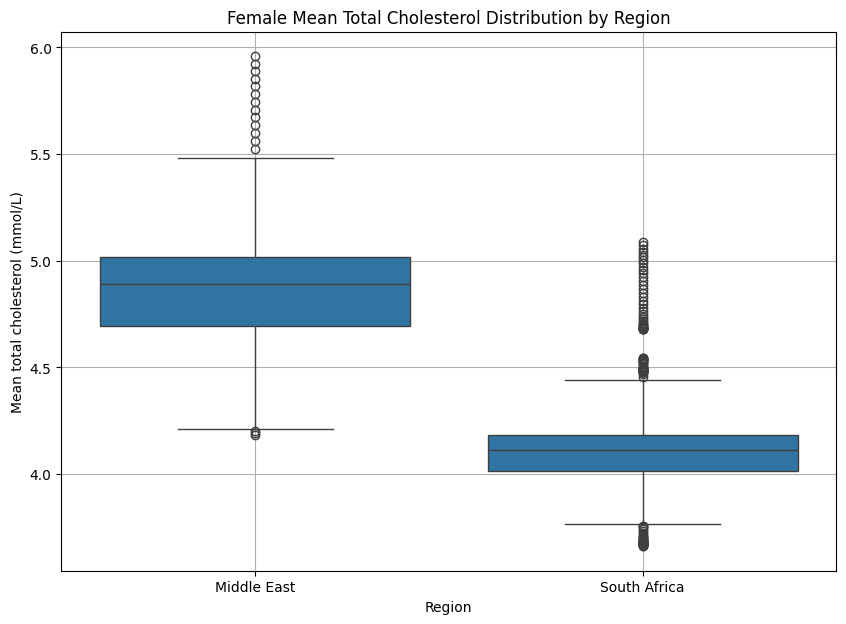

In [19]:
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.boxplot(x='Region', y='Mean total cholesterol (mmol/L)', data=female_df[female_df['Region'] != 'Other'])
plt.title('Female Mean Total Cholesterol Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Mean total cholesterol (mmol/L)')
plt.grid(True)
plt.show()

In [20]:
print('Unique countries in Middle East:', female_df[female_df['Region'] == 'Middle East']['Country/Region/World'].nunique())
print('Unique countries in South Africa:', female_df[female_df['Region'] == 'South Africa']['Country/Region/World'].nunique())


Unique countries in Middle East: 15
Unique countries in South Africa: 12


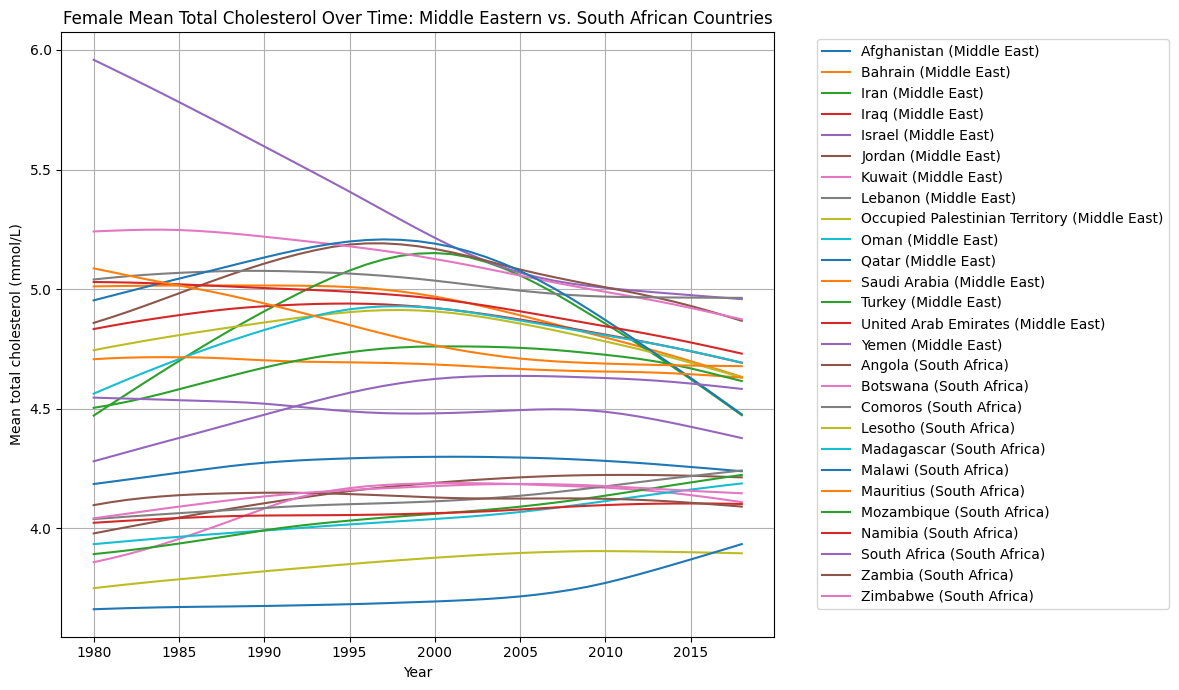

In [17]:
middle_eastern_countries = [
    'Afghanistan', 'Bahrain', 'Iran', 'Iraq', 'Israel', 'Jordan', 'Kuwait',
    'Lebanon', 'Oman', 'Occupied Palestinian Territory', 'Qatar', 'Saudi Arabia',
    'Syria', 'Turkey', 'United Arab Emirates', 'Yemen'
]
south_african_countries = [
    'South Africa', 'Angola', 'Botswana', 'Comoros', 'Eswatini', 'Lesotho', 'Madagascar',
    'Malawi', 'Mauritius', 'Mozambique', 'Namibia', 'Zambia', 'Zimbabwe'
]

female_df = df[df['Sex'] == 'Women']

middle_eastern_female_df = female_df[female_df['Country/Region/World'].isin(middle_eastern_countries)]
south_african_female_df = female_df[female_df['Country/Region/World'].isin(south_african_countries)]

plt.figure(figsize=(12, 7))

for country in middle_eastern_female_df['Country/Region/World'].unique():
    country_df = middle_eastern_female_df[middle_eastern_female_df['Country/Region/World'] == country]
    plt.plot(country_df['Year'], country_df['Mean total cholesterol (mmol/L)'], label=f'{country} (Middle East)')

for country in south_african_female_df['Country/Region/World'].unique():
    country_df = south_african_female_df[south_african_female_df['Country/Region/World'] == country]
    plt.plot(country_df['Year'], country_df['Mean total cholesterol (mmol/L)'], label=f'{country} (South Africa)')

plt.title('Female Mean Total Cholesterol Over Time: Middle Eastern vs. South African Countries')
plt.xlabel('Year')
plt.ylabel('Mean total cholesterol (mmol/L)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
print(df['Country/Region/World'])

7800     Afghanistan
7801     Afghanistan
7802     Afghanistan
7803     Afghanistan
7804     Afghanistan
            ...     
15595       Zimbabwe
15596       Zimbabwe
15597       Zimbabwe
15598       Zimbabwe
15599       Zimbabwe
Name: Country/Region/World, Length: 7800, dtype: object


In [22]:
middle_eastern_countries = [
    'Afghanistan', 'Bahrain', 'Iran', 'Iraq', 'Israel', 'Jordan', 'Kuwait',
    'Lebanon', 'Oman', 'Occupied Palestinian Territory', 'Qatar', 'Saudi Arabia',
    'Syria', 'Turkey', 'United Arab Emirates', 'Yemen'
]

In [23]:
middle_eastern_countries = [
    'Afghanistan', 'Bahrain', 'Iran', 'Iraq', 'Israel', 'Jordan', 'Kuwait',
    'Lebanon', 'Oman', 'Occupied Palestinian Territory', 'Qatar', 'Saudi Arabia',
    'Syria', 'Turkey', 'United Arab Emirates', 'Yemen'
]

middle_eastern_countries_df = df[df['Country/Region/World'].isin(middle_eastern_countries)]
other_countries_df = df[~df['Country/Region/World'].isin(middle_eastern_countries)]

print("Middle Eastern Countries DataFrame shape:", middle_eastern_countries_df.shape)
print("Other Countries DataFrame shape:", other_countries_df.shape)
print("\nHead of Middle Eastern Countries DataFrame:")
print(middle_eastern_countries_df.head())
print("\nHead of Other Countries DataFrame:")
print(other_countries_df.head())

Middle Eastern Countries DataFrame shape: (585, 6)
Other Countries DataFrame shape: (7215, 6)

Head of Middle Eastern Countries DataFrame:
     Country/Region/World  ISO    Sex  Year  Mean total cholesterol (mmol/L)  \
7800          Afghanistan  AFG  Women  1980                         4.185578   
7801          Afghanistan  AFG  Women  1981                         4.195018   
7802          Afghanistan  AFG  Women  1982                         4.204503   
7803          Afghanistan  AFG  Women  1983                         4.213971   
7804          Afghanistan  AFG  Women  1984                         4.223569   

           Region  
7800  Middle East  
7801  Middle East  
7802  Middle East  
7803  Middle East  
7804  Middle East  

Head of Other Countries DataFrame:
     Country/Region/World  ISO    Sex  Year  Mean total cholesterol (mmol/L)  \
7839              Albania  ALB  Women  1980                         5.233215   
7840              Albania  ALB  Women  1981                     

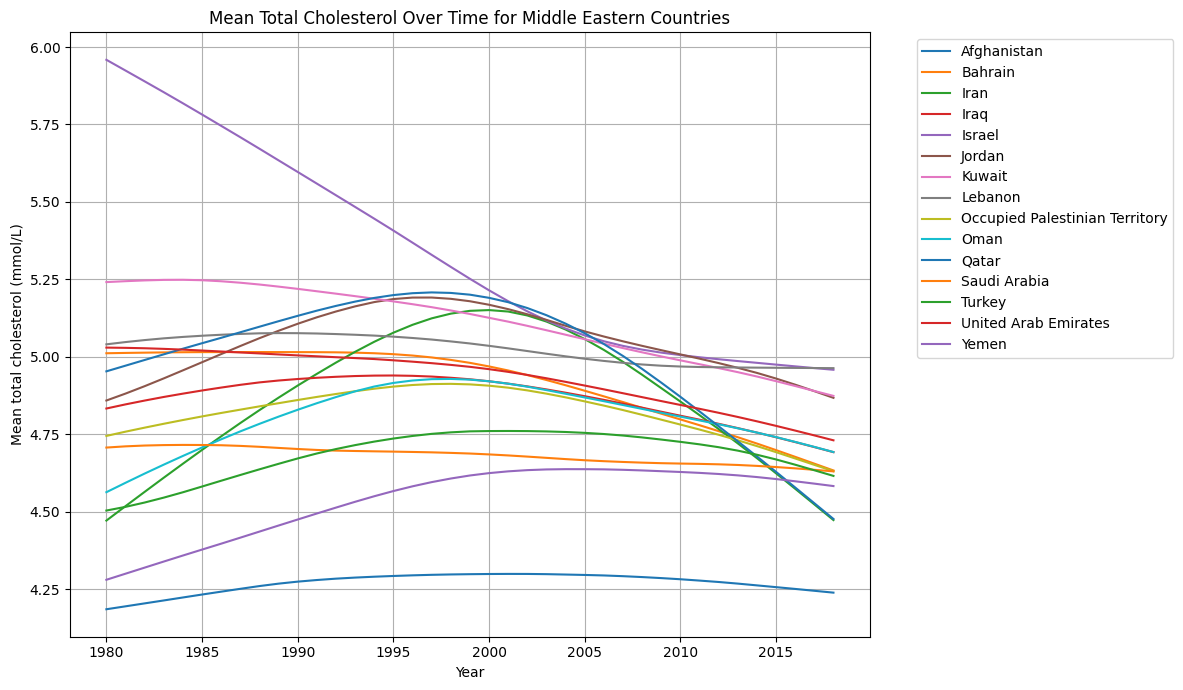

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

for country in middle_eastern_countries_df['Country/Region/World'].unique():
    country_data = middle_eastern_countries_df[middle_eastern_countries_df['Country/Region/World'] == country]
    plt.plot(country_data['Year'], country_data['Mean total cholesterol (mmol/L)'], label=country)

plt.title('Mean Total Cholesterol Over Time for Middle Eastern Countries')
plt.xlabel('Year')
plt.ylabel('Mean total cholesterol (mmol/L)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

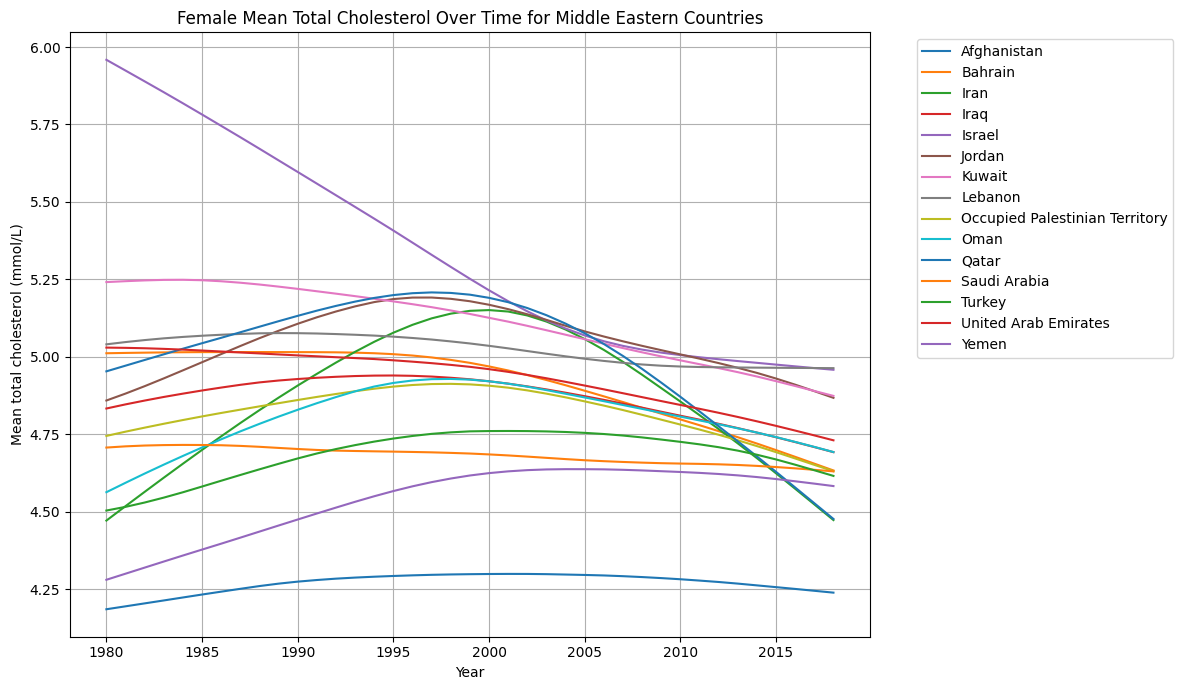

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

for country in middle_eastern_female_df['Country/Region/World'].unique():
    country_data = middle_eastern_female_df[middle_eastern_female_df['Country/Region/World'] == country]
    plt.plot(country_data['Year'], country_data['Mean total cholesterol (mmol/L)'], label=country)

plt.title('Female Mean Total Cholesterol Over Time for Middle Eastern Countries')
plt.xlabel('Year')
plt.ylabel('Mean total cholesterol (mmol/L)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

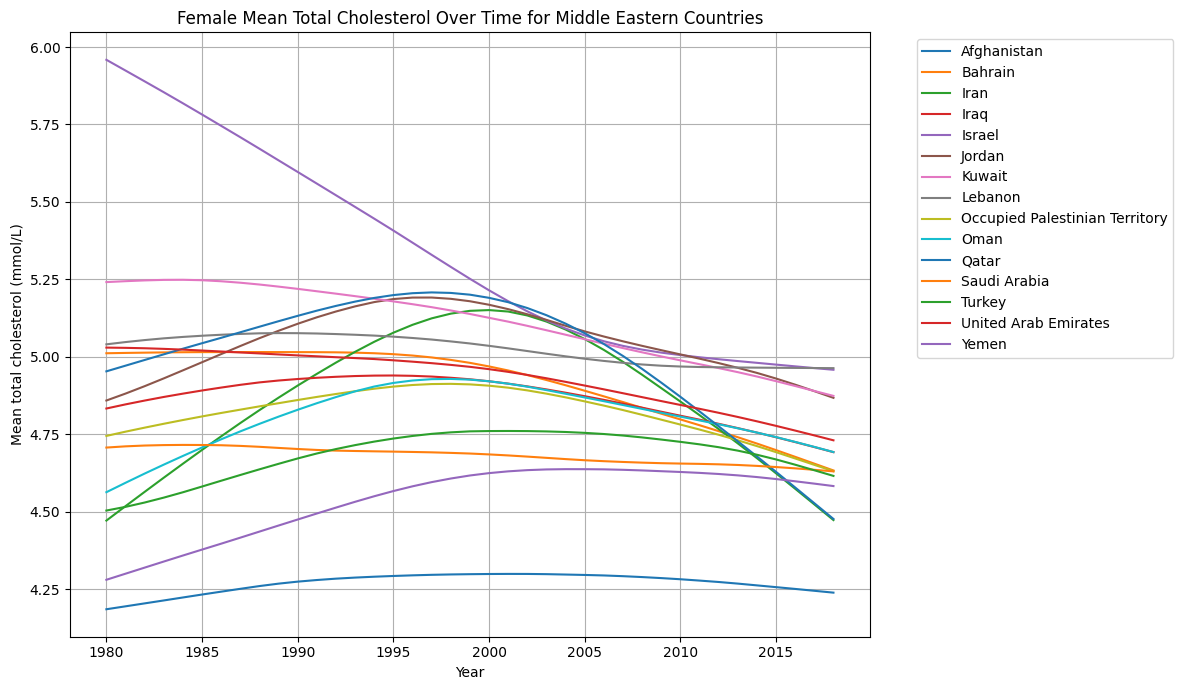

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

for country in middle_eastern_female_df['Country/Region/World'].unique():
    country_data = middle_eastern_female_df[middle_eastern_female_df['Country/Region/World'] == country]
    plt.plot(country_data['Year'], country_data['Mean total cholesterol (mmol/L)'], label=country)

plt.title('Female Mean Total Cholesterol Over Time for Middle Eastern Countries')
plt.xlabel('Year')
plt.ylabel('Mean total cholesterol (mmol/L)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

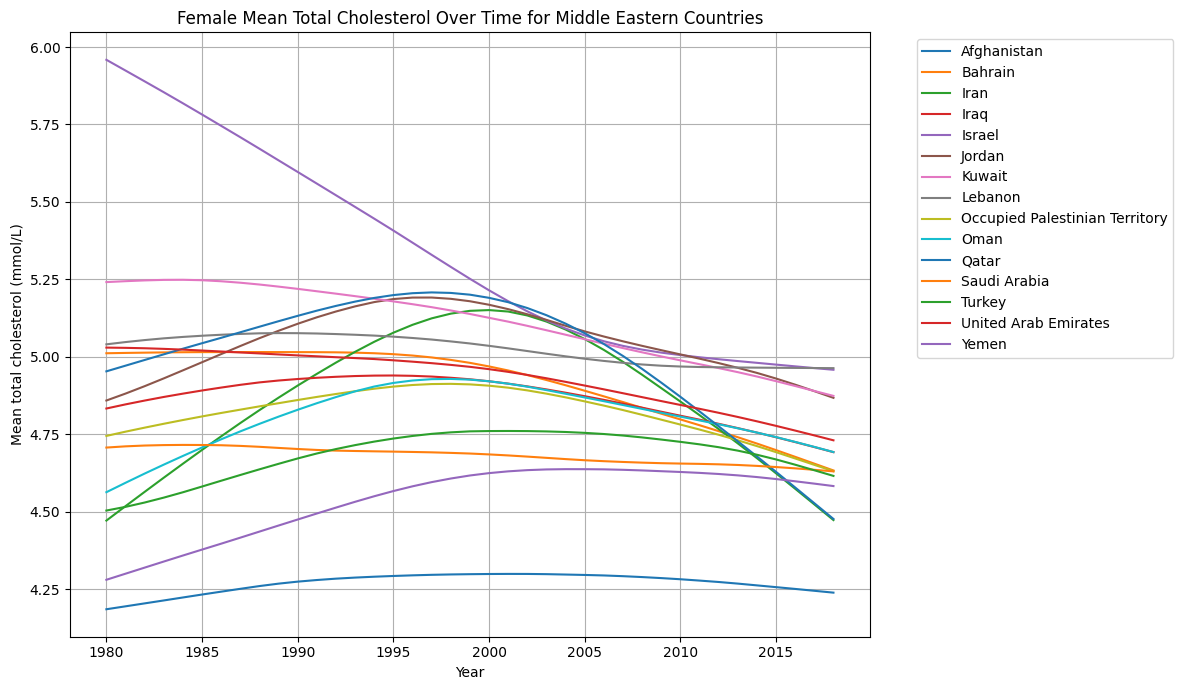

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

for country in middle_eastern_female_df['Country/Region/World'].unique():
    country_data = middle_eastern_female_df[middle_eastern_female_df['Country/Region/World'] == country]
    plt.plot(country_data['Year'], country_data['Mean total cholesterol (mmol/L)'], label=country)

plt.title('Female Mean Total Cholesterol Over Time for Middle Eastern Countries')
plt.xlabel('Year')
plt.ylabel('Mean total cholesterol (mmol/L)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

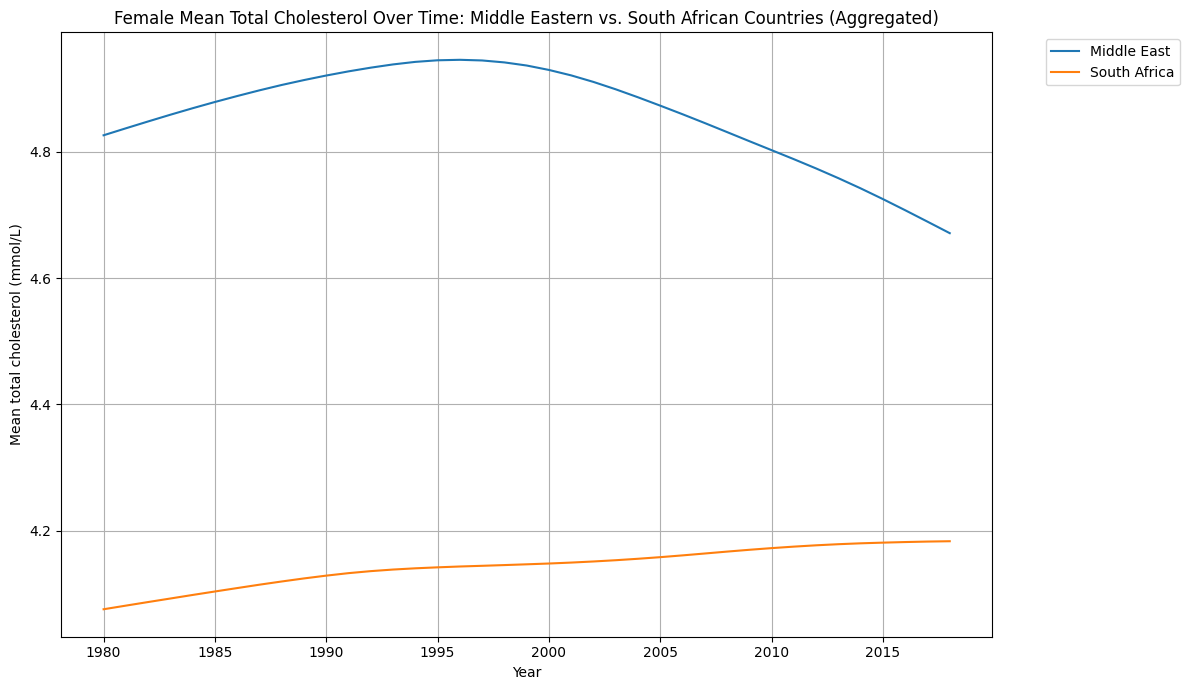

In [31]:
middle_eastern_countries = [
    'Afghanistan', 'Bahrain', 'Iran', 'Iraq', 'Israel', 'Jordan', 'Kuwait',
    'Lebanon', 'Oman', 'Occupied Palestinian Territory', 'Qatar', 'Saudi Arabia',
    'Syria', 'Turkey', 'United Arab Emirates', 'Yemen'
]
south_african_countries = [
    'South Africa', 'Angola', 'Botswana', 'Comoros', 'Eswatini', 'Lesotho', 'Madagascar',
    'Malawi', 'Mauritius', 'Mozambique', 'Namibia', 'Zambia', 'Zimbabwe'
]

female_df = df[df['Sex'] == 'Women']

middle_eastern_female_df = female_df[female_df['Country/Region/World'].isin(middle_eastern_countries)]
south_african_female_df = female_df[female_df['Country/Region/World'].isin(south_african_countries)]

# Calculate mean cholesterol for each region per year
middle_eastern_mean_cholesterol = middle_eastern_female_df.groupby('Year')['Mean total cholesterol (mmol/L)'].mean().reset_index()
south_african_mean_cholesterol = south_african_female_df.groupby('Year')['Mean total cholesterol (mmol/L)'].mean().reset_index()

plt.figure(figsize=(12, 7))

plt.plot(
    middle_eastern_mean_cholesterol['Year'],
    middle_eastern_mean_cholesterol['Mean total cholesterol (mmol/L)'],
    label='Middle East'
)

plt.plot(
    south_african_mean_cholesterol['Year'],
    south_african_mean_cholesterol['Mean total cholesterol (mmol/L)'],
    label='South Africa'
)

plt.title('Female Mean Total Cholesterol Over Time: Middle Eastern vs. South African Countries (Aggregated)')
plt.xlabel('Year')
plt.ylabel('Mean total cholesterol (mmol/L)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


Yearly Average Female Mean Total Cholesterol (mmol/L):
 Year  Middle East Average (mmol/L)  South Africa Average (mmol/L)
 1980                      4.825725                       4.076195
 1981                      4.836748                       4.081918
 1982                      4.847595                       4.087595
 1983                      4.858231                       4.093182
 1984                      4.868507                       4.098807
 1985                      4.878375                       4.104283
 1986                      4.887781                       4.109691
 1987                      4.896799                       4.115040
 1988                      4.905287                       4.120108
 1989                      4.913032                       4.124942
 1990                      4.920221                       4.129357
 1991                      4.926791                       4.133290
 1992                      4.932657                       4.136472
 1993 

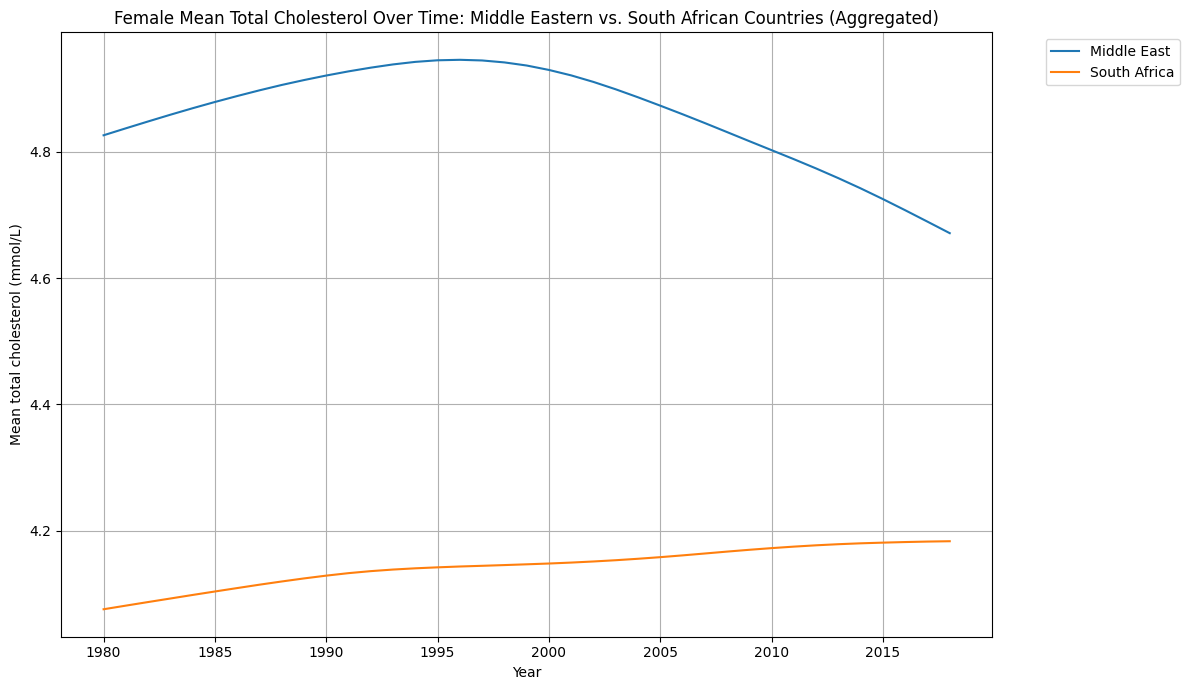

In [32]:
# Create a combined table of yearly averages
combined_yearly_avg = pd.merge(
    middle_eastern_mean_cholesterol.rename(columns={'Mean total cholesterol (mmol/L)': 'Middle East Average (mmol/L)'}),
    south_african_mean_cholesterol.rename(columns={'Mean total cholesterol (mmol/L)': 'South Africa Average (mmol/L)'}),
    on='Year',
    how='outer'
)

print("\nYearly Average Female Mean Total Cholesterol (mmol/L):")
print(combined_yearly_avg.to_string(index=False))

# Plot the yearly averages
plt.figure(figsize=(12, 7))

plt.plot(
    middle_eastern_mean_cholesterol['Year'],
    middle_eastern_mean_cholesterol['Mean total cholesterol (mmol/L)'],
    label='Middle East'
)

plt.plot(
    south_african_mean_cholesterol['Year'],
    south_african_mean_cholesterol['Mean total cholesterol (mmol/L)'],
    label='South Africa'
)

plt.title('Female Mean Total Cholesterol Over Time: Middle Eastern vs. South African Countries (Aggregated)')
plt.xlabel('Year')
plt.ylabel('Mean total cholesterol (mmol/L)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
from scipy import stats

t_stat, p_val = stats.ttest_ind(combined_yearly_avg['Middle East Average (mmol/L)'],
                                  combined_yearly_avg['South Africa Average (mmol/L)'])

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_val}")

T-statistic: 53.232162859493066
P-value: 6.465409705139657e-62


In [34]:
t_stat, p_val = stats.ttest_ind(middle_eastern_mean_cholesterol['Mean total cholesterol (mmol/L)'],
                                  south_african_mean_cholesterol['Mean total cholesterol (mmol/L)'])

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_val}")





T-statistic: 53.232162859493066
P-value: 6.465409705139657e-62


In [35]:
# Calculate the difference in cholesterol level for Middle Eastern women from 1980 to 2018
middle_east_1980_cholesterol = middle_eastern_mean_cholesterol[middle_eastern_mean_cholesterol['Year'] == 1980]['Mean total cholesterol (mmol/L)'].iloc[0]
middle_east_2018_cholesterol = middle_eastern_mean_cholesterol[middle_eastern_mean_cholesterol['Year'] == 2018]['Mean total cholesterol (mmol/L)'].iloc[0]
diff_middle_east = middle_east_2018_cholesterol - middle_east_1980_cholesterol
print(f"Difference in mean total cholesterol for Middle Eastern women (2018 - 1980): {diff_middle_east:.4f} mmol/L")

# Calculate the difference in cholesterol level for South African women from 1980 to 2018
south_africa_1980_cholesterol = south_african_mean_cholesterol[south_african_mean_cholesterol['Year'] == 1980]['Mean total cholesterol (mmol/L)'].iloc[0]
south_africa_2018_cholesterol = south_african_mean_cholesterol[south_african_mean_cholesterol['Year'] == 2018]['Mean total cholesterol (mmol/L)'].iloc[0]
diff_south_africa = south_africa_2018_cholesterol - south_africa_1980_cholesterol
print(f"Difference in mean total cholesterol for South African women (2018 - 1980): {diff_south_africa:.4f} mmol/L")


Difference in mean total cholesterol for Middle Eastern women (2018 - 1980): -0.1548 mmol/L
Difference in mean total cholesterol for South African women (2018 - 1980): 0.1076 mmol/L


In [36]:
middle_eastern_countries = [
 "Afghanistan", "Bahrain", "Iran", "Iraq", "Israel", "Jordan",
 "Kuwait", "Lebanon", "Oman", "Occupied Palestinian Territory",
 "Qatar", "Saudi Arabia", "Syria", "Turkey",
 "United Arab Emirates", "Yemen"
]
southern_african_countries = [
 "South Africa", "Angola", "Botswana", "Comoros", "Eswatini",
 "Lesotho", "Madagascar", "Malawi", "Mauritius", "Mozambique",
 "Namibia", "Zambia", "Zimbabwe"
]
selected_countries = (
 middle_eastern_countries + southern_african_countries
)
analysis_df = df[
 (df["Sex"] == "Women") &
 (df["Country/Region/World"].isin(selected_countries))
].copy()
analysis_df["region"] = np.where(
 analysis_df["Country/Region/World"].isin(middle_eastern_countries),
 "Middle East",
 "Southern Africa"
)
print(
 analysis_df.groupby("region")["Country/Region/World"].nunique()
)

region
Middle East        15
Southern Africa    12
Name: Country/Region/World, dtype: int64


In [37]:
countries_in_data = set(df["Country/Region/World"])
missing_countries = [
 country for country in selected_countries
 if country not in countries_in_data
]
print("Countries not found:", missing_countries)

Countries not found: ['Syria', 'Eswatini']


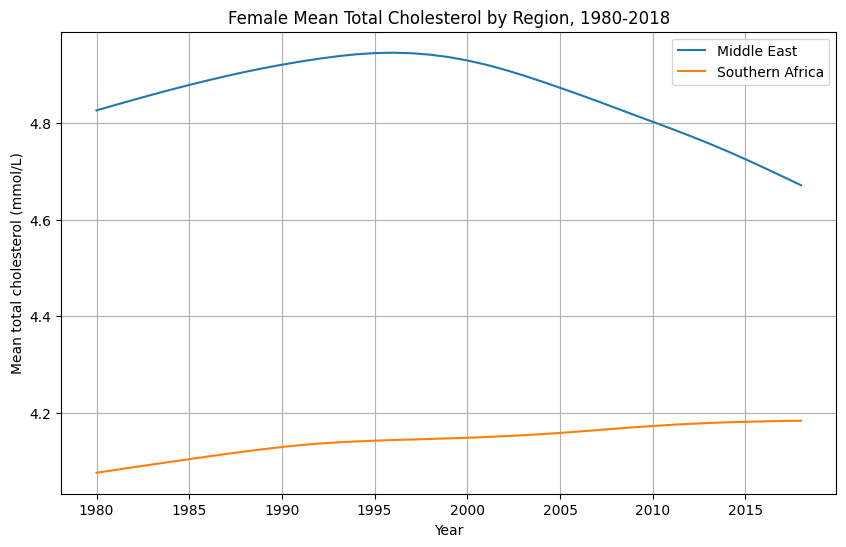

In [38]:
regional_yearly = (
 analysis_df
 .groupby(["region", "Year"], as_index=False)
 ["Mean total cholesterol (mmol/L)"]
 .mean()
)
plt.figure(figsize=(10, 6))
for region in regional_yearly["region"].unique():
 region_data = regional_yearly[
 regional_yearly["region"] == region
 ]
 plt.plot(
 region_data["Year"],
 region_data["Mean total cholesterol (mmol/L)"],
 label=region
 )
plt.title("Female Mean Total Cholesterol by Region, 1980-2018")
plt.xlabel("Year")
plt.ylabel("Mean total cholesterol (mmol/L)")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
endpoints = (
 analysis_df[
 analysis_df["Year"].isin([1980, 2018])
 ]
 .pivot(
 index=["Country/Region/World", "region"],
 columns="Year",
 values="Mean total cholesterol (mmol/L)"
 )
 .dropna()
 .reset_index()
)
endpoints["change_1980_2018"] = (
 endpoints[2018] - endpoints[1980]
)
print(endpoints.head(29))

Year            Country/Region/World           region      1980      2018  \
0                        Afghanistan      Middle East  4.185578  4.239159   
1                             Angola  Southern Africa  3.979220  4.213532   
2                            Bahrain      Middle East  5.011731  4.633465   
3                           Botswana  Southern Africa  3.858977  4.110138   
4                            Comoros  Southern Africa  4.039216  4.242317   
5                               Iran      Middle East  4.471718  4.473369   
6                               Iraq      Middle East  4.833395  4.692576   
7                             Israel      Middle East  5.958708  4.958386   
8                             Jordan      Middle East  4.859200  4.867862   
9                             Kuwait      Middle East  5.241332  4.874122   
10                           Lebanon      Middle East  5.040488  4.963661   
11                           Lesotho  Southern Africa  3.750375  3.896104   

/tmp/ipykernel_1287/1003293641.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


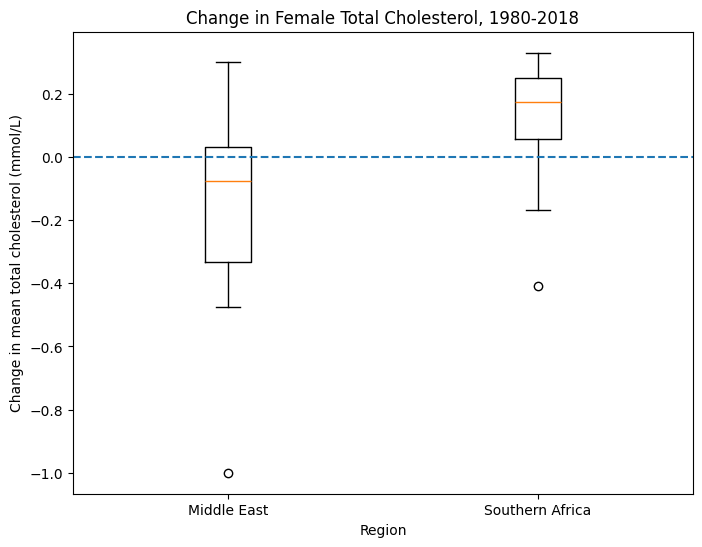

In [40]:
middle_east_change = endpoints.loc[
 endpoints["region"] == "Middle East",
 "change_1980_2018"
]
southern_africa_change = endpoints.loc[
 endpoints["region"] == "Southern Africa",
 "change_1980_2018"
]
plt.figure(figsize=(8, 6))
plt.boxplot(
 [middle_east_change, southern_africa_change],
 labels=["Middle East", "Southern Africa"]
)
plt.axhline(0, linestyle="--")
plt.title("Change in Female Total Cholesterol, 1980-2018")
plt.xlabel("Region")
plt.ylabel("Change in mean total cholesterol (mmol/L)")
plt.show()


In [41]:
from scipy import stats

t_statistic, p_value = stats.ttest_ind(
 middle_east_change,
 southern_africa_change,
 equal_var=False
)
print("Middle East mean change:", middle_east_change.mean())
print("Southern Africa mean change:", southern_africa_change.mean())
print("T-statistic:", t_statistic)
print("P-value:", p_value)

Middle East mean change: -0.15480202547484864
Southern Africa mean change: 0.10756923962114513
T-statistic: -2.5616146178494086
P-value: 0.017001413302909055


In [42]:
n1 = len(middle_east_change)
n2 = len(southern_africa_change)
pooled_sd = np.sqrt(
 ((n1 - 1) * middle_east_change.var(ddof=1) +
 (n2 - 1) * southern_africa_change.var(ddof=1)) /
 (n1 + n2 - 2)
)
cohens_d = (
 middle_east_change.mean() -
 southern_africa_change.mean()
) / pooled_sd
print("Cohen's d:", cohens_d)

Cohen's d: -0.9501730769800714


**Reasoning**:
Generate the time series plot using seaborn with distinct colors and improved aesthetics to visualize the trend of female mean total cholesterol over time for Middle Eastern and Southern African countries.



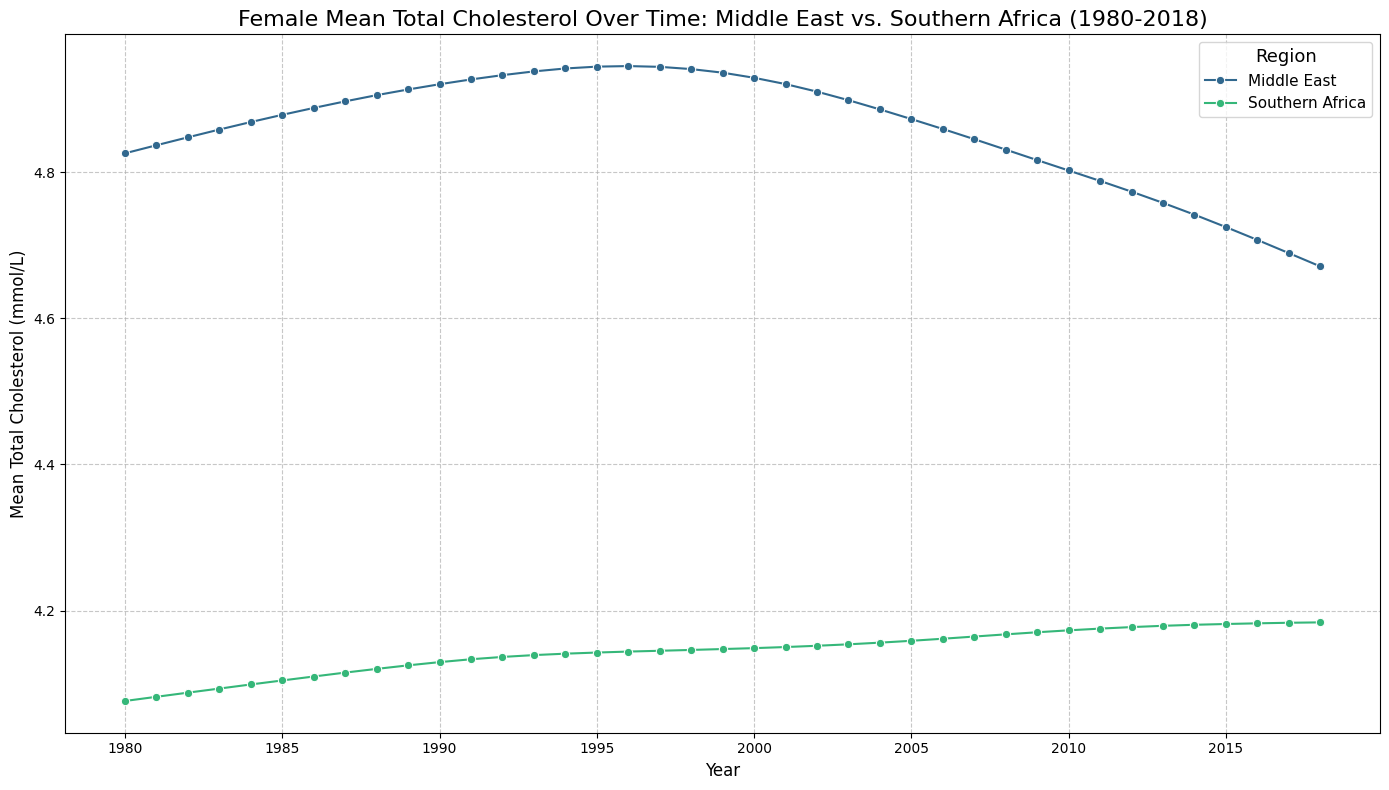

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
sns.lineplot(data=regional_yearly, x='Year', y='Mean total cholesterol (mmol/L)', hue='region', marker='o', palette='viridis')

plt.title('Female Mean Total Cholesterol Over Time: Middle East vs. Southern Africa (1980-2018)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Mean Total Cholesterol (mmol/L)', fontsize=12)
plt.legend(title='Region', title_fontsize='13', fontsize='11')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1287/1866444642.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='region', y='change_1980_2018', data=endpoints, palette='coolwarm', width=0.5)


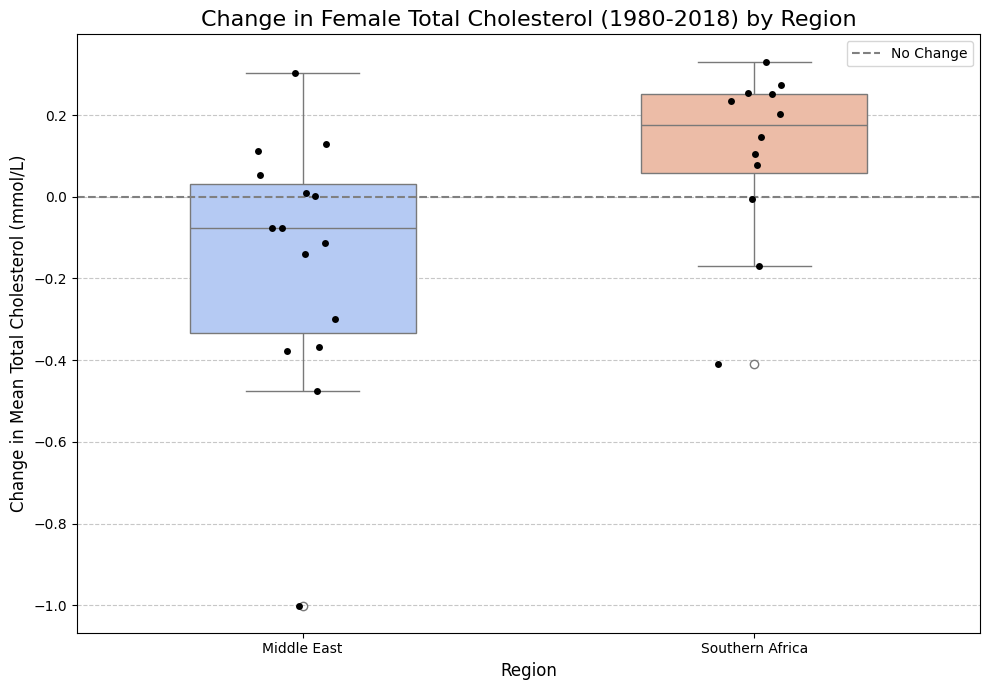

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.boxplot(x='region', y='change_1980_2018', data=endpoints, palette='coolwarm', width=0.5)
sns.stripplot(x='region', y='change_1980_2018', data=endpoints, color='black', size=5, jitter=True)
plt.axhline(0, color='gray', linestyle='--', linewidth=1.5, label='No Change')

plt.title('Change in Female Total Cholesterol (1980-2018) by Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Change in Mean Total Cholesterol (mmol/L)', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()